### Applying classification with various models and datasets 

In [2]:
import kagglehub
#from autonotebook import tqdm as notebook_tqdm

# Download latest version
path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)

Path to dataset files: /Users/inuit/.cache/kagglehub/datasets/uciml/iris/versions/2


In [3]:
import pandas as pd

data = "/Users/inuit/.cache/kagglehub/datasets/uciml/iris/versions/2/Iris.csv"
data = pd.read_csv(data)
y = pd.factorize(data['Species'])[0]
X = data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

dt1 = DecisionTreeClassifier(max_depth=2)
dt2 = DecisionTreeClassifier(max_depth=5)
dt1.fit(X_train, y_train)
dt2.fit(X_train, y_train)

y_1 = dt1.predict(X_test)
y_2 = dt2.predict(X_test)

a1 = accuracy_score(y_test, y_1)
a2 = accuracy_score(y_test, y_2)

print(f"Accuracy scores:\n Decision tree 1 (max depth 2): {a1}\t Decision tree 1 (max depth 2): {a2}\n")


Accuracy scores:
 Decision tree 1 (max depth 2): 0.98	 Decision tree 1 (max depth 2): 0.98



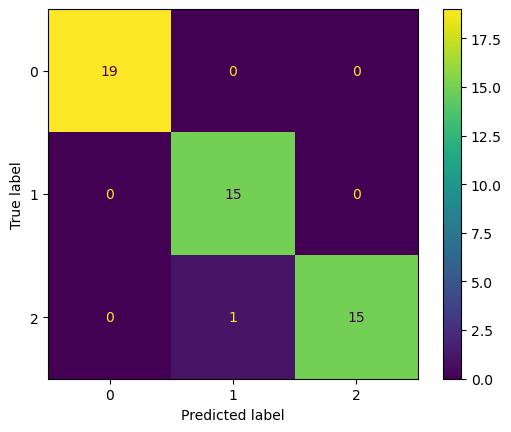

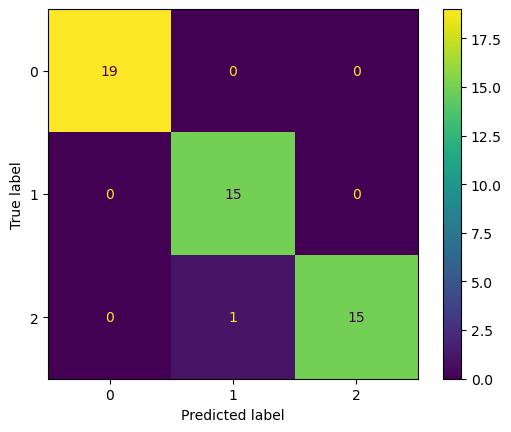

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_1, labels=dt1.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt1.classes_)
disp.plot()
cm = confusion_matrix(y_test, y_2, labels=dt2.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt2.classes_)
disp.plot()
plt.show()

That was a little to easy. 

In [6]:
# pick a more challenging dataset
import gc

gc.collect()

# see https://www.kaggle.com/datasets/nalisha/early-wakeup-health-and-lifestyle-dataset for more
path = kagglehub.dataset_download("nalisha/early-wakeup-health-and-lifestyle-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/inuit/.cache/kagglehub/datasets/nalisha/early-wakeup-health-and-lifestyle-dataset/versions/1


In [ ]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

data = pd.read_csv("/Users/inuit/.cache/kagglehub/datasets/nalisha/early-wakeup-health-and-lifestyle-dataset/versions/1/early_wakeup_health_dataset.csv")
y = data['Early_Waker'].map(lambda x: 1 if x == 'Yes' else 0)
X = data[data.columns.drop(['Early_Waker', 'Person_ID', 'Wake_Up_Time',	'Sleep_Time']).to_list()]
cols = X.select_dtypes('str').columns.to_list()
ordinal_encoder = OrdinalEncoder()
X[cols] = ordinal_encoder.fit_transform(X[cols])
missing = X.isna().sum()
missing_cols = missing[missing > 0 ].index.size
#print(f"There are {X.isna().any(axis=1).values.sum()} rows with missing values...")
#print(f"and {X.isna().sum().values.sum()} values missing in columns.")
#print(f"Columns will be dropped since the nan values are found in {missing_cols} columns.")
X.dropna(axis=1, inplace=True)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

dt1 = DecisionTreeClassifier(max_depth=2)
dt2 = DecisionTreeClassifier(max_depth=5)
dt3 = DecisionTreeClassifier(max_depth=8)
dt1.fit(X_train, y_train)
dt2.fit(X_train, y_train)
dt3.fit(X_train, y_train)
y_1 = dt1.predict(X_test)
y_2 = dt2.predict(X_test)
y_3 = dt3.predict(X_test)

a1 = accuracy_score(y_test, y_1)
a2 = accuracy_score(y_test, y_2)
a3 = accuracy_score(y_test, y_3)

print(f"Accuracy scores:\n Decision tree 1 (max depth 2): {a1}\t Decision tree 2 (max depth 5): {a2}\t Decision tree 3 (max depth 3): {a3}\n")

There are 3576 rows with missing values...
and 4662 values missing in columns.
Columns will be dropped since the nan values are found in 3 columns.
Accuracy scores:
 Decision tree 1 (max depth 2): 0.6893939393939394	 Decision tree 2 (max depth 5): 0.7187878787878788	 Decision tree 3 (max depth 3): 0.6845454545454546



### Logistic Regression

In [68]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression(max_iter=10000, tol=0.1, penalty='l2')
logistic.fit(X_train, y_train)
logistic.score(X_test, y_test)


/Users/inuit/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


0.7466666666666667

### RandomForests

In [65]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
rfc.score(X_test, y_test)

0.7321212121212122

### XGBoost

In [66]:
from sklearn.ensemble import GradientBoostingClassifier
clf = GradientBoostingClassifier().fit(X_train, y_train)
clf.score(X_test, y_test)

0.7369696969696969

### Support Vector Machines


In [88]:
from sklearn.svm import LinearSVC
clf = LinearSVC().fit(X_train, y_train)
clf.score(X_test, y_test)


0.7512121212121212

In [89]:
from sklearn.svm import SVR
clf = SVR().fit(X_train, y_train)
clf.score(X_test, y_test)

-0.4087619766866395

### K-nearest neighbours

In [69]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'KNN accuracy (k=2): {accuracy:.4f}')

KNN accuracy (k=2): 0.5597


### Naive Bayes

In [73]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Naive Bayes accuracy: {accuracy:.4f}')

Naive Bayes accuracy: 0.6564


In [ ]:
# do gridsearch cv 
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

import warnings
warnings.simplefilter("ignore")

models = [
    (
        "LinearSVC",
        Pipeline([("scaler", StandardScaler()), ("clf", LinearSVC(max_iter=5000, random_state=42))]),
        {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__tol": [1e-4, 1e-3, 1e-2],
        },
    ),
    (
        "LogisticRegression",
        Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=5000, random_state=42))]),
        {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__penalty": ["l2"],
            "clf__solver": ["lbfgs"],
        },
    ),
    (
        "XGBoost",
        XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
        {
            "n_estimators": [50, 100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "subsample": [0.8, 1.0],
        },
    ),
]

results = []
for name, estimator, param_grid in models:
    grid = GridSearchCV(estimator, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    results.append((name, grid.best_params_, grid.best_score_, test_acc))
    print(f"{name}: best_params={grid.best_params_}, cv_accuracy={grid.best_score_:.4f}, test_accuracy={test_acc:.4f}")


In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
warnings.simplefilter("ignore")

pipeline = Pipeline([
("scaler", StandardScaler()),
("feature_selection", SelectFromModel(
estimator=LogisticRegression(max_iter=5000, random_state=42, C= 1, penalty='l2', solver='lbfgs'),
threshold="median"
)),
("clf",LogisticRegression(max_iter=5000, random_state=42, C= 1, penalty='l2', solver='lbfgs')),
])

cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)

pipeline.fit(X_train, y_train)
selected_features = pipeline.named_steps["feature_selection"].get_support().sum()
test_accuracy = pipeline.score(X_test, y_test)

print("Selected features:", selected_features)
print("CV accuracies:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Held-out test accuracy:", test_accuracy)


Selected features: 29
CV accuracies: [0.74666667 0.74833333 0.77777778 0.75888889 0.74611111]
Mean CV accuracy: 0.7555555555555555
Held-out test accuracy: 0.743
